In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import precision_recall_curve

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

1,383,526 observations, 133 colonnes


In [3]:
x_train, x_test, y_train, y_test = split_data(df)

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)


In [4]:
def clean_feature_names(df):
    """Remplace les caractères spéciaux dans les noms de colonnes par des underscores."""
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

x_train_lgbm = clean_feature_names(x_train)
x_test_lgbm  = clean_feature_names(x_test)

FEATURES_LGBM = list(x_train_lgbm.columns)
print(f'{len(FEATURES_LGBM)} features après nettoyage')
print('Exemple de noms nettoyés :', FEATURES_LGBM[:5])

107 features après nettoyage
Exemple de noms nettoyés : ['Sexe', 'Compte_personnel____ge', 'Est_salari___', 'Nb_d_ayant_droit', 'Nb_de_r_cla_depuis_mai_2023']


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=  23.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_samples=50, n_estimators=300, num_leaves=31, reg_alpha=0, reg_lambda=0, subsample=1.0; total time=  34.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=  53.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, min_child_samples=50, n_estimators=300, num_leaves=31, reg_alpha=0, reg_lambda=0, subsample=1.0; total time= 1.1min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0, reg_lambda=0, subsample=0.7; total time= 1.1min
[CV] END colsample_bytree=1.0, learning_

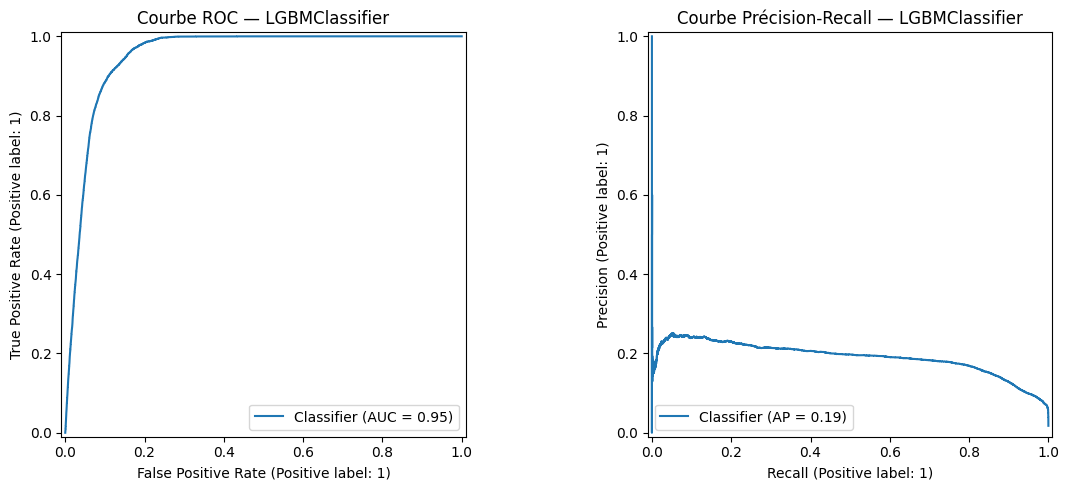

Modèle sauvegardé dans models/lightgbm_insee.pkl


'models/lightgbm_insee.pkl'

In [5]:
param_dist = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [4, 6, 8, -1],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'min_child_samples': [20, 50, 100],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0, 0.1, 0.5],
}

model_base = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=model_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

search.fit(x_train_lgbm, y_train)

print(f'\nMeilleurs paramètres : {search.best_params_}')
print(f'Meilleure AUC en CV  : {search.best_score_:.4f}')

best_model = search.best_estimator_
metrics = evaluate(best_model, x_test, y_test)
save_model(best_model,'lightgbm_insee')

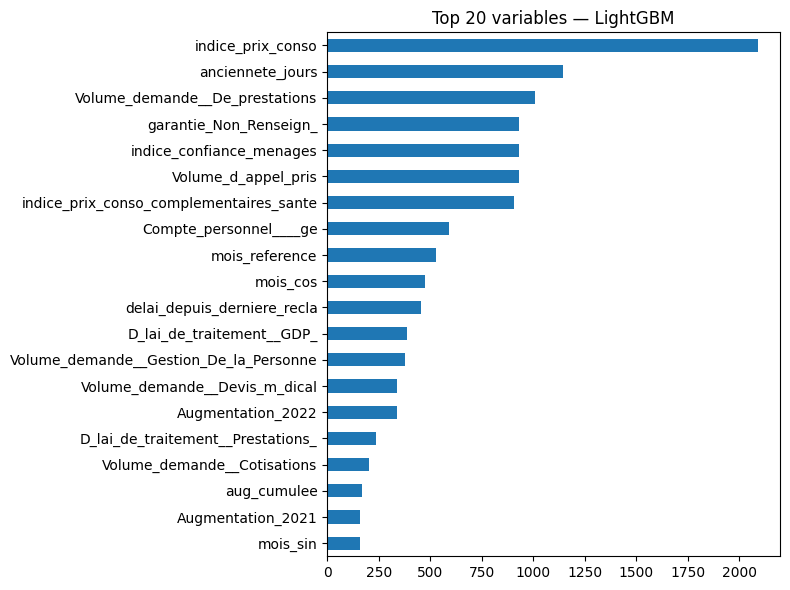

In [6]:
importances = pd.Series(best_model.feature_importances_, index=FEATURES_LGBM)
importances.sort_values(ascending=False).head(20).plot(
    kind='barh', figsize=(8, 6)
)
plt.title('Top 20 variables — LightGBM')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()